In [1]:
import random
import matplotlib.pyplot as plt

class IowaGamblingEnvironment:
    def __init__(self, starting_balance=2000, max_turns=100):
        self.starting_balance = starting_balance
        self.max_turns = max_turns
        self.reset()

        # Standard Iowa Gambling Task Deck configurations
        self.decks = {
            'A': {'win': 100, 'penalties': [0, 0, 0, 0, 0, 150, 200, 250, 300, 350]},
            'B': {'win': 100, 'penalties': [1250] * 1 + [0] * 9},
            'C': {'win': 50,  'penalties': [0, 0, 0, 0, 0, 25, 50, 50, 50, 75]},
            'D': {'win': 50,  'penalties': [250] * 1 + [0] * 9}
        }

    def reset(self):
        """Resets the environment for a new test run."""
        self.balance = self.starting_balance
        self.turns = 0
        self.history = [self.balance]
        self.choice_history = []
        return {
            "balance": self.balance,
            "turn": self.turns,
            "done": False
        }

    def step(self, deck_choice):
        """
        Executes one turn in the task.

        Parameters:
            deck_choice (str): 'A', 'B', 'C', or 'D'

        Returns:
            dict: The result of the action and current state of the game.
        """
        deck_choice = str(deck_choice).strip().upper()
        if deck_choice not in self.decks:
            raise ValueError("Invalid choice! Choose from 'A', 'B', 'C', or 'D'.")

        if self.turns >= self.max_turns:
            return {"error": "Game already complete. Please call reset().", "done": True}

        # Calculate rewards and penalties
        win = self.decks[deck_choice]['win']
        penalty = random.choice(self.decks[deck_choice]['penalties'])
        net_change = win - penalty

        # Update internal states
        self.balance += net_change
        self.turns += 1
        self.history.append(self.balance)
        self.choice_history.append(deck_choice)

        done = self.turns >= self.max_turns

        # Return data payload for your API processing
        return {
            "turn": self.turns,
            "choice_made": deck_choice,
            "reward_received": win,
            "penalty_received": penalty,
            "net_change": net_change,
            "current_balance": self.balance,
            "done": done
        }

    def plot_results(self):
        """Plots performance visualization after the run completes."""
        plt.figure(figsize=(12, 5))

        # Plot 1: Balance over time
        plt.subplot(1, 2, 1)
        plt.plot(self.history, marker='o', linestyle='-', color='b', markersize=3)
        plt.axhline(y=self.starting_balance, color='r', linestyle='--', label='Starting Balance')
        plt.title('AI Performance: Balance Over Time')
        plt.xlabel('Turn')
        plt.ylabel('Balance ($)')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Plot 2: Distribution of choices
        plt.subplot(1, 2, 2)
        deck_counts = [self.choice_history.count(d) for d in ['A', 'B', 'C', 'D']]
        plt.bar(['Deck A', 'Deck B', 'Deck C', 'Deck D'], deck_counts, color=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
        plt.title('AI Deck Selection Distribution')
        plt.ylabel('Number of Choices')

        plt.tight_layout()
        plt.show()

Starting Task Evaluation. Initial Balance: $2000

Turn 1: AI chose D | Net: $50 (+50/-0) | New Balance: $2050
Turn 2: AI chose B | Net: $100 (+100/-0) | New Balance: $2150
Turn 3: AI chose C | Net: $0 (+50/-50) | New Balance: $2150
Turn 4: AI chose D | Net: $50 (+50/-0) | New Balance: $2200
Turn 5: AI chose D | Net: $50 (+50/-0) | New Balance: $2250
Turn 6: AI chose B | Net: $100 (+100/-0) | New Balance: $2350
Turn 7: AI chose B | Net: $100 (+100/-0) | New Balance: $2450
Turn 8: AI chose D | Net: $50 (+50/-0) | New Balance: $2500
Turn 9: AI chose A | Net: $100 (+100/-0) | New Balance: $2600
Turn 10: AI chose A | Net: $-250 (+100/-350) | New Balance: $2350
Turn 11: AI chose B | Net: $-1150 (+100/-1250) | New Balance: $1200
Turn 12: AI chose C | Net: $-25 (+50/-75) | New Balance: $1175
Turn 13: AI chose A | Net: $100 (+100/-0) | New Balance: $1275
Turn 14: AI chose D | Net: $50 (+50/-0) | New Balance: $1325
Turn 15: AI chose A | Net: $100 (+100/-0) | New Balance: $1425
Turn 16: AI chose 

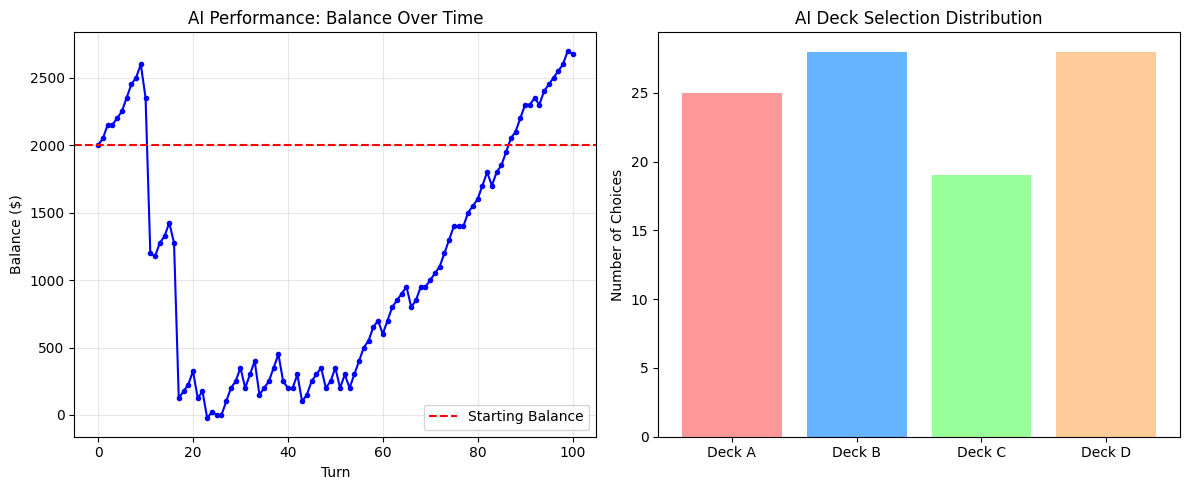

In [2]:
# 1. Initialize the Environment
env = IowaGamblingEnvironment(max_turns=100)
initial_state = env.reset()

# 2. Define a placeholder function representing your AI API client
def mock_ai_api_call(current_balance, turn_number):
    """
    Replace the logic inside this function with your actual API call.
    Your prompt payload would pass the current balance and history to the model,
    and return its text choice ('A', 'B', 'C', or 'D').
    """
    # Example mock AI behavior: Picks entirely at random
    return random.choice(['A', 'B', 'C', 'D'])

# 3. Run the Evaluation Loop
state = initial_state
print(f"Starting Task Evaluation. Initial Balance: ${state['balance']}\n")

while not state['done']:
    # Format the variables to send to your AI model
    current_balance = state.get('current_balance', env.starting_balance)
    turn_number = state['turn']

    # Get the selection string from your model
    ai_choice = mock_ai_api_call(current_balance, turn_number)

    # Push the choice into the environment
    state = env.step(ai_choice)

    # Optional print statements to track execution in the Colab output logs
    print(f"Turn {state['turn']}: AI chose {state['choice_made']} | "
          f"Net: ${state['net_change']} (+{state['reward_received']}/-{state['penalty_received']}) | "
          f"New Balance: ${state['current_balance']}")

# 4. Process and view the final telemetry
print("\nEvaluation Complete!")
print(f"Final AI Balance: ${env.balance}")
env.plot_results()